# Processing Workflows

While the descriptions from the first notebook are nice, they're not research data or archival metadata.

This next section details a workflow that will process your materials into a structured format that can be used for research or library systems. This is an example that can be adapted to your specific needs.



In [ ]:
!pip install -q langchain==0.3.27 langchain-core==0.3.79 langgraph nest-asyncio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.4/155.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.3/208.3 kB 9.3 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

img_path = '/content/drive/MyDrive/fantastic_futures_img/'
assert Path(img_path).exists()

# Sending your files to the model

For many models, you just need to provide an image's URL on the Internet.  The model will fetch the image and encode it for you. However, for local files on your computer, you'll need to send your data to the model for processing.

The most common way to do this is to encode the binary data in your file as a string of characters using the base64 encoding system.  So rather than sending ones and zeros over the Internet, we'll be sending packets of text characters.  On the other end, the model turns that data back into an image file to process.

In [ ]:
import base64
from pathlib import Path

def encode_images(image_directory: str, file_extensions: list = ['.jpg', '.png'], data_uri: bool = True):
    """Generator to encode images in the specified directory to base64 strings.

    Args:
        image_directory (Path): The directory containing images to encode.
        file_extensions (list, optional): List of file extensions to consider. Defaults to ['.jpg', '.png'].
        data_uri (bool, optional): If True, includes the data URI scheme in the output. Defaults to True.

    Yields:
        str: Base64 encoded string of each image.
    """
    image_directory = Path(image_directory)
    if not image_directory.is_dir():
        raise ValueError(f"The provided path {image_directory} is not a valid directory.")
    image_paths = [p for p in image_directory.iterdir() if p.suffix.lower() in file_extensions]
    for path in image_paths:
        with open(path, 'rb') as img_file:
            encoded_string = base64.b64encode(img_file.read()).decode('utf-8')
            if data_uri:
                mime_type = 'image/jpeg' if path.suffix.lower() == '.jpg' else 'image/png'
                yield path, f"data:{mime_type};base64,{encoded_string}"
            else:
                yield path, encoded_string




In [ ]:
img_generator = encode_images(img_path)
img_data = next(img_generator)
print('filename: ', img_data[0].name), print(img_data[1][:200])

filename:  0003.jpg
data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQABAAD//gAXR2VuZXJhdGVkIGJ5IElJUEltYWdl/9sAQwADAgIDAgIDAwMDBAMDBAUIBQUEBAUKBwcGCAwKDAwLCgsLDQ4SEA0OEQ4LCxAWEBETFBUVFQwPFxgWFBgSFBUU/9sAQwEDBAQFBAUJBQUJFA0LD


(None, None)

In [ ]:
from google.colab import userdata

base_url="https://dashscope-intl.aliyuncs.com/compatible-mode/v1"
api_key= userdata.get('DASHSCOPE_API_KEY') # This is the same key you used earlier
model="qwen-vl-ocr"

In [ ]:
# @title Code to send the encoded image to the server
import os
import asyncio
import aiohttp
from openai import AsyncOpenAI
from tqdm.asyncio import tqdm

# Use AsyncOpenAI instead of OpenAI
client = AsyncOpenAI(
    api_key=api_key,
    base_url=base_url,
)

async def process_image(img: tuple, session: aiohttp.ClientSession, semaphore: asyncio.Semaphore):
    """Process a single image with rate limiting and timeout"""
    async with semaphore:  # Limit concurrent requests
        image_path = img[0]
        image_b64 = img[1]
        file = {
            "name": image_path.name,
        }
        #print(f"Starting to process: {image_path.name}")

        try:
            # Add timeout to API call as well
            completion = await asyncio.wait_for(
                client.chat.completions.create(
                    model=model,
                    messages=[
                        {
                            "role": "user",
                            "content": [
                                {
                                    "type": "text",
                                    "text": "Extract text from the image. Preserve reading order. Return text as markdown."
                                },
                                {
                                    "type": "image_url",
                                    "image_url": {
                                        "url": image_b64
                                    }
                                }
                            ]
                        }
                    ],
                ),
                timeout=360  # 360 second timeout for API call
            )
            #print(f"Successfully processed: {image_path.name}")
            file["markdown_text"] = completion.choices[0].message.content
            return file
        except asyncio.TimeoutError:
            print(f"API timeout for image {image_path.name}")
            return None
        except Exception as e:
            print(f"Error processing image {image_path.name}: {e}")
            return None

async def process_all_images(images, max_concurrent=3):
    """Process all images concurrently with a limit on concurrent requests"""
    # Create aiohttp session for connection pooling
    connector = aiohttp.TCPConnector(limit=10, limit_per_host=5)
    timeout = aiohttp.ClientTimeout(total=300)  # 5 minute total timeout

    async with aiohttp.ClientSession(connector=connector, timeout=timeout) as session:
        semaphore = asyncio.Semaphore(max_concurrent)

        # Create tasks for all images
        tasks = [process_image(image, session, semaphore) for image in images]

        # Process with progress bar
        results = []
        completed_count = 0

        for task in tqdm.as_completed(tasks, total=len(tasks), desc="Processing images"):
            try:
                result = await task
                completed_count += 1
                if result is not None:
                    results.append(result)
                #print(f"Completed {completed_count}/{len(tasks)} images")
            except Exception as e:
                print(f"Task failed with error: {e}")
                completed_count += 1

    return results



# State

As we move from step to step in the workflow, we will need something to store the data from prior steps and to make that data available. This object is often called "state" in programming. In the cell below, we create a simple state object to hold our data as we move through the workflow.

Given that we're processing a box of archival materials, I have called it "Box." I find it helpful to think of the fields in the object as columns in a spreadsheet. Each field (box_manifest_uri, image_uris...) gives us a placeholder for information that we'd like to gather during the workflow. How you design your state object can be helpful in deciding what steps are needed in the workflow and what your final output should look like.

In [ ]:
# https://langchain-ai.github.io/langgraph/tutorials/workflows/#prompt-chaining
# https://typing.python.org/en/latest/spec/typeddict.html

from typing_extensions import TypedDict


class Box(TypedDict):  # Level: File in EAP
    box_manifest_uri: str
    box_manifest_data: dict
    box_metadata: dict
    box_summary: str
    image_urls: list[str]
    image_height: int
    image_width: int
    images: list[dict]
    item_grouping: list
    items: dict
    image_descriptions: bool
    start_index: int  # Start processing from this image index
    end_index: int  # End processing at this image index
    file_lookup: dict

# Steps in the Workflow

In [ ]:
# @title Code that details what to do at each step of the workflow
import re
import json
import requests
import srsly
from rich import print
from tqdm.asyncio import tqdm
from pathlib import Path
import nest_asyncio
from openai import OpenAI



# helper functions for the cleaning step
def remove_code_tags(text):
    """Remove code tags (triple backticks) from the text. Also remove tags with language specifiers such as ```yaml."""
    return re.sub(r"```[a-zA-Z]*\n(.*?)\n```", r"\1", text, flags=re.DOTALL)

def remove_repeated_phrases(text):
    """Remove repeated phrases in the text."""
    # This regex looks for any phrase (sequence of words) that is repeated consecutively
    pattern = r"(\b\w+(?: \w+){0,5}\b)( \1)+"
    return re.sub(pattern, r"\1", text)

# https://docs.langchain.com/oss/python/langgraph/workflows-agents


# Steps
def load_manifest(state: Box) -> Box:
    if Path(f'{img_path}/info.json').exists():
        info = srsly.read_json(f'{img_path}/info.json')
        manifest_url = info.get('url', None)
        header = {
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/11"
        }
        manifest = requests.get(manifest_url, headers=header)
        if manifest.status_code != 200:
            raise Exception(f"Error downloading manifest: {manifest.status_code}")

        manifest = manifest.json()
        metadata = {}
        for item in manifest["metadata"]:
            metadata[item["label"]] = item["value"]
        print(f"Loaded manifest for {metadata.get('Identifier', 'unknown_box')}")
        file_lookup = info['images']
        return {
            "box_metadata": metadata,
            "file_lookup": file_lookup
        }
    else:
        print("info.json not found in img/ directory. Please retry downloading the files")


def text_recognition(state: Box) -> Box:
    """Extract text from images using OCR (synchronous wrapper).

    This step prefers to use an already-produced `output` variable (from a prior
    async cell). If `output` isn't available it will attempt to run the
    async processing, applying nest_asyncio when running inside a Jupyter
    event loop. If nest_asyncio isn't available, instruct the user to run the
    async cell to produce `output`.
    """

    # If the async cell has already produced `output`, reuse it (fast and safe).
    if "output" in globals() and isinstance(output, list):
        print("✅ Using existing OCR results...")
        state["images"] = output
        return state

    # Otherwise attempt to run the async processing synchronously.
    print("🔍 Starting text recognition...")

    # Count images for progress display
    #img_dir = Path("img")
    #image_files = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))
    #print(f"📊 Found {len(image_files)} images to process")

    images_gen = encode_images(img_path)
    try:
        loop = asyncio.get_event_loop()
    except RuntimeError:
        # No running loop, create and run one
        print("🚀 Creating new event loop...")
        state["images"] = asyncio.run(process_all_images(images_gen, max_concurrent=15))
        return state

    # If we're in a running event loop (typical in Jupyter), try nest_asyncio to allow run_until_complete.
    if loop.is_running():
        try:
            #print("⚙️ Applying nest_asyncio for Jupyter compatibility...")
            nest_asyncio.apply(loop)
            state["images"] = loop.run_until_complete(process_all_images(images_gen, max_concurrent=15))
            return state
        except Exception as e:
            print(f"❌ Error with nest_asyncio: {e}")
            raise RuntimeError(
                "Cannot run async OCR inside the current event loop. "
                "Either install `nest_asyncio` or run the async cell that awaits `process_all_images(...)` "
                "so that a global `output` variable is available."
            )

    # If event loop not running, run the coroutine directly
    print("🔄 Running coroutine directly...")
    state["images"] = loop.run_until_complete(process_all_images(images_gen, max_concurrent=15))
    return state

def entity_recognition(state: Box) -> Box:
    """Recognize entities in the extracted text."""
    from tqdm import tqdm

    print("🏷️ Starting entity recognition...")
    images = state["images"]
    client = OpenAI(base_url=base_url, api_key=api_key)

    for image in tqdm(images, desc="Extracting entities"):
        text = image["markdown_text"]
        prompt = f"Identify and list all named entities (people, places, organizations, dates) mentioned in the following text:\n\n{text}\n\n Be sure to note the context of the entity (i.e. a Person is a witness at a trial, or the driver of a car). Return the entities as a JSON array."
        chat_completion = client.chat.completions.create(
            model="qwen3-vl-flash", #"Qwen/Qwen3-VL-8B-Instruct",
            messages=[
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": prompt},
                    ],
                }
            ],
            temperature=0,
            # max_tokens = 100
        )
        response = chat_completion.choices[0].message.content
        try:
            response = json.loads(response)
        except json.JSONDecodeError:
            response = "[error: invalid JSON]" + response

        image["entities"] = response
    state["images"] = images
    return state

def clean_response(state: Box) -> Box:
    """Clean the model response by removing code tags and repeated phrases."""
    from tqdm import tqdm

    print("🧹 Cleaning responses...")
    images = state["images"]
    for image in tqdm(images, desc="Cleaning text"):
        text = image["markdown_text"]
        text = remove_code_tags(text)
        text = remove_repeated_phrases(text)
        image["cleaned_text"] = text
        image["image_uri"] = state["file_lookup"].get(image["name"], "")
    state["images"] = images
    return state

def save_state(state: Box) -> Box:
    box_id = (
        state["box_metadata"]
        .get("Identifier", "unknown_box")
        .replace(" ", "_")
        .replace("/", "_")
    )
    # if not output directory, create it
    import os

    os.makedirs("output", exist_ok=True)
    with open(f"output/{box_id}.json", "w") as f:
        json.dump(state, f, indent=4)
    print(f"💾 Saved processed state to output/{box_id}.json")
    return state

In [ ]:
from langgraph.graph import StateGraph, START, END


# Build workflow
builder = StateGraph(Box)

# Add nodes
builder.add_node("load_manifest", load_manifest)
builder.add_node("text_recognition", text_recognition)
builder.add_node("entity_recognition", entity_recognition)
builder.add_node("clean_response", clean_response)
builder.add_node("save_state", save_state)

# Add edges to connect nodes
builder.add_edge(START, "load_manifest")
builder.add_edge("load_manifest", "text_recognition")
builder.add_edge("text_recognition", "entity_recognition")
builder.add_edge("entity_recognition", "clean_response")
builder.add_edge("clean_response", "save_state")
builder.add_edge("save_state", END)

# Compile
graph = builder.compile()

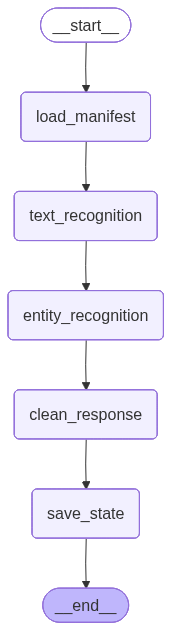

In [ ]:
# Create a diagram of the workflow

from IPython.display import Image as IPythonImage

display(IPythonImage(graph.get_graph().draw_mermaid_png()))

In [ ]:
# needed to run async in Jupyter
import nest_asyncio
nest_asyncio.apply()

In [ ]:
# Invoke

output = graph.invoke({})

Loaded manifest for EAP617/1/10

🔍 Starting text recognition...

Processing images: 100%|██████████| 159/159 [01:16<00:00,  2.08it/s]


🏷️ Starting entity recognition...

Extracting entities:   8%|▊         | 13/159 [01:35<17:46,  7.31s/it]


KeyboardInterrupt: 

In [ ]:
# Save our ouput on Drive
import shutil
import os

source_dir = '/content/output'
destination_dir = '/content/drive/MyDrive/fantastic_futures_img/output'

os.makedirs(destination_dir, exist_ok=True)

for item in os.listdir(source_dir):
    s = os.path.join(source_dir, item)
    d = os.path.join(destination_dir, item)
    if os.path.isdir(s):
        shutil.copytree(s, d, symlinks=False, ignore=None)
    else:
        shutil.copy2(s, d)
print(f"Contents of {source_dir} copied to {destination_dir}")

Contents of /content/output copied to /content/drive/MyDrive/fantastic_futures_img/output